# MABe22 mouse-triplets end-to-end template

Pose-tracked example using MABe22 **mouse triplets** — 3 mice per video, 12 keypoints each, with behavior annotations (e.g. *chases*). Demonstrates the N>2 animals case: 3 unique pairs → 6 pair/perspective rows per frame.

Pipeline: MABe22 `.npy` → tracks parquet + labels NPZ → `PairPoseDistancePCA` + `PairEgocentricFeatures` → `PairWavelet` (on both) → global t-SNE / KMeans / Ward → XGBoost supervised classifier.

**Source paper**: Sun et al. 2023, *[MABe22](https://arxiv.org/abs/2207.10553)*. Dataset DOI: [10.22002/rdsa8-rde65](https://doi.org/10.22002/rdsa8-rde65).

### How this differs from the CalMS21 template

- **N=3 animals** instead of 2 — `PairPoseDistancePCA` / `PairEgocentricFeatures` automatically produce features for all 3 unique pairs.
- **12 keypoints** instead of 7 — pass `pose_n=12` and update neck/tail indices to match the MABe22 mouse skeleton.
- **Labels are sequence-level** (all animals share the same annotation track at each frame) — the dense NPZ format handles this; pair features each get the per-frame label via frame lookup.

In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from mosaic.behavior.feature_library import (
    ExtractLabeledTemplates,
    ExtractTemplates,
    GlobalKMeansClustering,
    GlobalScaler,
    GlobalTSNE,
    GlobalWardClustering,
    GroundTruthLabelsSource,
    Inputs,
    ResultColumn,
    TemporalStackingFeature,
    XgboostFeature,
)
from mosaic.core.analysis import compute_cluster_label_agreement
from mosaic.core.dataset import Dataset, new_dataset_manifest
from mosaic.core.pipeline import load_values


## Setup paths

In [2]:
# Raw MABe22 .npy dump. Override with:  export MABE22_DATA_ROOT=/path/to/mabe22
DATA_ROOT = Path(os.environ.get("MABE22_DATA_ROOT", "/home/jdavidson/mabe22"))

# Where this example's dataset (manifest, tracks, features, labels) will live.
EXAMPLE_ROOT = Path(
    os.environ.get("MOSAIC_EXAMPLE_ROOT", "./example_datasets/mabe22-mouse-triplets")
).resolve()
EXAMPLE_ROOT.mkdir(parents=True, exist_ok=True)

# Subset source file and the smaller file we'll write into tracks_raw/.
# Subsetting keeps runtime quick; edit N_SEQUENCES_SUBSET below to change.
SUBSET_SOURCE = DATA_ROOT / "mouse_user_train.npy"
TRACKS_RAW = EXAMPLE_ROOT / "tracks_raw"
TRACKS_RAW.mkdir(parents=True, exist_ok=True)
SUBSET_DST = TRACKS_RAW / "mouse_subset.npy"

print("DATA_ROOT:   ", DATA_ROOT)
print("EXAMPLE_ROOT:", EXAMPLE_ROOT)
print("source file: ", SUBSET_SOURCE, "exists:", SUBSET_SOURCE.exists())


DATA_ROOT:    /home/jdavidson/mabe22
EXAMPLE_ROOT: /home/jdavidson/mabe22/example_datasets/mabe22-mouse-triplets
source file:  /home/jdavidson/mabe22/mouse_user_train.npy exists: True


## Build a small subset of the raw MABe22 file

The full `mouse_user_train.npy` is ~420 MB. We subset to a small number of sequences to keep the demo tractable — increase for a fuller run.

In [3]:
# Build a small subset of the raw MABe22 file — fewer sequences = faster demo.
# Runs once; re-run with SUBSET_DST.unlink() first if you want to rebuild.
N_SEQUENCES_SUBSET = 10

if not SUBSET_DST.exists():
    raw = np.load(SUBSET_SOURCE, allow_pickle=True).item()
    seq_ids = list(raw["sequences"].keys())[:N_SEQUENCES_SUBSET]
    subset = {
        "vocabulary": raw.get("vocabulary", []),
        "sequences": {sid: raw["sequences"][sid] for sid in seq_ids},
    }
    np.save(SUBSET_DST, subset, allow_pickle=True)
    print(f"wrote {SUBSET_DST} with {len(seq_ids)} sequences")
else:
    print(f"subset already exists: {SUBSET_DST}")
    raw = np.load(SUBSET_DST, allow_pickle=True).item()
    print(f"  {len(raw['sequences'])} sequences, vocabulary={raw.get('vocabulary', [])}")


wrote /home/jdavidson/mabe22/example_datasets/mabe22-mouse-triplets/tracks_raw/mouse_subset.npy with 10 sequences


## Create dataset + convert tracks and labels

In [4]:
# Create dataset manifest (idempotent — skips if dataset.yaml already exists).
manifest_path = EXAMPLE_ROOT / "dataset.yaml"
if not manifest_path.exists():
    manifest_path = new_dataset_manifest(
        name="mabe22-mouse-triplets",
        base_dir=EXAMPLE_ROOT,
        version="0.1.0",
    )

dataset = Dataset(manifest_path=manifest_path).load()

# Index raw tracks — MABe22 stores many sequences in one .npy file.
dataset.index_tracks_raw(
    search_dirs=[TRACKS_RAW],
    patterns="*.npy",
    src_format="mabe22_npy",
    multi_sequences_per_file=True,
    group_from="filename",
    recursive=False,
)

# Convert raw .npy -> standardized per-sequence parquet.
dataset.convert_all_tracks(overwrite=False)

# Convert MABe22 annotation tracks -> dense per-frame behavior NPZ labels.
dataset.convert_all_labels(
    kind="behavior",
    source_format="mabe22_npy",
    overwrite=False,
)

print(dataset)


Wrote dataset manifest -> /home/jdavidson/mabe22/example_datasets/mabe22-mouse-triplets/dataset.yaml
[index_tracks_raw] 1 -> /home/jdavidson/mabe22/example_datasets/mabe22-mouse-triplets/tracks_raw/index.csv
[convert_all_labels] kind=behavior wrote 10 sequences using mabe22_npy converter (overwrite=False).
Dataset(manifest_path=PosixPath('/home/jdavidson/mabe22/example_datasets/mabe22-mouse-triplets/dataset.yaml'), name='mabe22-mouse-triplets', version='0.1.0', format='yaml', roots={'media_raw': 'media_raw', 'tracks_raw': 'tracks_raw', 'labels': 'labels', 'media': 'media', 'tracks': 'tracks', 'features': 'features', 'models': 'models', 'frames': 'media/frames'}, meta={'labels': {'behavior': {'index': '/home/jdavidson/mabe22/example_datasets/mabe22-mouse-triplets/labels/behavior/index.csv', 'label_format': 'dense', 'updated_at': '2026-05-03T22:39:15.638803+00:00'}}}, dataset_type='discrete', segment_duration=None, time_column=None)


## Feature pipeline — pose path

Same pose pipeline as CalMS21, parameterized for the MABe22 mouse skeleton (12 keypoints). Check the MABe22 paper for the exact keypoint order — the `neck_idx` / `tail_base_idx` here are reasonable defaults; adjust if your skeleton definition differs.

In [6]:
from mosaic.behavior.feature_library import (
    PairEgocentricFeatures,
    PairPoseDistancePCA,
    PairWavelet,
)

# MABe22 mouse skeleton: 12 keypoints per animal.
# Indices here are placeholders — consult the paper's keypoint list
# and adjust if your neck/tail indices differ.
POSE_N = 12
NECK_IDX = 3
TAIL_BASE_IDX = 9

feat_pose = PairPoseDistancePCA(
    params={"n_components": 6, "pose": {"pose_n": POSE_N}},
)
pose_result = dataset.run_feature(
    feat_pose, parallel_workers=4, parallel_mode="process",
)
print(pose_result)


[feature:pair-posedistance-pca__from__tracks] completed run_id=0.1-50e66c19dc -> /home/jdavidson/ecodylic_local_sync/mosaic/example_datasets/mabe22-mouse-triplets/features/pair-posedistance-pca__from__tracks/0.1-50e66c19dc
Result(feature='pair-posedistance-pca__from__tracks', run_id='0.1-50e66c19dc')


[pair-posedistance-pca__from__tracks] Processed 10/10 sequences


In [7]:
feat_ego = PairEgocentricFeatures(
    params={
        "neck_idx": NECK_IDX,
        "tail_base_idx": TAIL_BASE_IDX,
        "pose": {"pose_n": POSE_N},
    },
)
ego_result = dataset.run_feature(
    feat_ego, parallel_workers=4, parallel_mode="process",
)
print(ego_result)


[feature:pair-egocentric__from__tracks] completed run_id=0.1-0f89eedcee -> /home/jdavidson/ecodylic_local_sync/mosaic/example_datasets/mabe22-mouse-triplets/features/pair-egocentric__from__tracks/0.1-0f89eedcee
Result(feature='pair-egocentric__from__tracks', run_id='0.1-0f89eedcee')


[pair-egocentric__from__tracks] Processed 10/10 sequences


In [8]:
wavelet_params = {
    "f_min": 0.2,
    "f_max": 5.0,
    "n_freq": 25,
    "wavelet": "cmor1.5-1.0",
    "log_floor": -3.0,
    "sampling": {"fps_default": 30.0},
}

feat_wave_social = PairWavelet(Inputs((pose_result,)), params=wavelet_params)
social_wave_result = dataset.run_feature(
    feat_wave_social, parallel_workers=4, parallel_mode="process",
)

feat_wave_ego = PairWavelet(Inputs((ego_result,)), params=wavelet_params)
ego_wave_result = dataset.run_feature(
    feat_wave_ego, parallel_workers=4, parallel_mode="process",
)


[pair-wavelet__from__pair-posedistance-pca__from__tracks] Processed 10/10 sequences


[feature:pair-wavelet__from__pair-posedistance-pca__from__tracks] completed run_id=0.1-0fe8fc37d4 -> /home/jdavidson/ecodylic_local_sync/mosaic/example_datasets/mabe22-mouse-triplets/features/pair-wavelet__from__pair-posedistance-pca__from__tracks/0.1-0fe8fc37d4
[feature:pair-wavelet__from__pair-egocentric__from__tracks] completed run_id=0.1-ce6de1e0ff -> /home/jdavidson/ecodylic_local_sync/mosaic/example_datasets/mabe22-mouse-triplets/features/pair-wavelet__from__pair-egocentric__from__tracks/0.1-ce6de1e0ff


[pair-wavelet__from__pair-egocentric__from__tracks] Processed 10/10 sequences


## Global embedding and clustering

In [9]:
# 1. Fit global scaler on 2000 random templates from the wavelet features.
templates = ExtractTemplates(
    Inputs((social_wave_result, ego_wave_result)),
    params={"n_templates": 2000},
)
templates_result = dataset.run_feature(templates)

scaler = GlobalScaler(
    Inputs((social_wave_result, ego_wave_result)),
    params={
        "templates": ExtractTemplates.TemplatesArtifact().from_result(templates_result),
    },
)
scaler_result = dataset.run_feature(scaler)

# 2. Re-extract 2000 farthest-first templates on the scaled features,
#    then fit t-SNE for visualization.
scaled_templates = ExtractTemplates(
    Inputs((scaler_result,)),
    params={"n_templates": 2000, "strategy": "farthest_first"},
)
scaled_templates_result = dataset.run_feature(scaled_templates)

tsne = GlobalTSNE(
    Inputs((scaled_templates_result,)),
    params={
        "perplexity": 50,
        "templates": ExtractTemplates.TemplatesArtifact().from_result(scaled_templates_result),
    },
)
tsne_result = dataset.run_feature(tsne)


[extract-templates__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks] Processed 10/10 sequences


[feature:extract-templates__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks] completed run_id=0.1-21b530f230 -> /home/jdavidson/ecodylic_local_sync/mosaic/example_datasets/mabe22-mouse-triplets/features/extract-templates__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks/0.1-21b530f230


[global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks] Processed 10/10 sequences


[feature:global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks] completed run_id=0.1-f5d8b98246 -> /home/jdavidson/ecodylic_local_sync/mosaic/example_datasets/mabe22-mouse-triplets/features/global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks/0.1-f5d8b98246


[extract-templates__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks] Processed 10/10 sequences


[feature:extract-templates__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks] completed run_id=0.1-a966aaea6b -> /home/jdavidson/ecodylic_local_sync/mosaic/example_datasets/mabe22-mouse-triplets/features/extract-templates__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks/0.1-a966aaea6b
[feature:global-tsne__from__extract-templates__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks] completed run_id=0.4-d67dbc9f0c -> /home/jdavidson/ecodylic_local_sync/mosaic/example_datasets/mabe22-mouse-triplets/features/global-tsne__from__extract-templates__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks/0.4-d67dbc9f0c


[global-tsne__from__extract-templates__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks] Processed 10/10 sequences


In [10]:
# KMeans at two granularities.
kmeans_results = []
for k in [50, 100]:
    kmeans = GlobalKMeansClustering(
        Inputs((scaled_templates_result,)),
        params={
            "k": int(k),
            "templates": ExtractTemplates.TemplatesArtifact().from_result(scaled_templates_result),
            "label_artifact_points": True,
        },
    )
    k_result = dataset.run_feature(kmeans)
    kmeans_results.append({"k": int(k), "run": k_result})


[global-kmeans__from__extract-templates__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks] Processed 10/10 sequences


[feature:global-kmeans__from__extract-templates__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks] completed run_id=0.4-ae80754af8 -> /home/jdavidson/ecodylic_local_sync/mosaic/example_datasets/mabe22-mouse-triplets/features/global-kmeans__from__extract-templates__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks/0.4-ae80754af8
[feature:global-kmeans__from__extract-templates__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks] completed run_id=0.4-1b485a4abd -> /home/jdavidson/ecodylic_local_sync/mosaic/example_datasets/mabe22-mouse-triplets/features/global-kmeans__from__extract-templates__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks/0.4-1b485a4abd


[global-kmeans__from__extract-templates__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks] Processed 10/10 sequences


In [11]:
# Ward hierarchical clustering for comparison.
ward_results = []
for cut in [25, 50, 100]:
    ward = GlobalWardClustering(
        Inputs((scaled_templates_result,)),
        params={
            "templates": ExtractTemplates.TemplatesArtifact().from_result(scaled_templates_result),
            "method": "ward",
            "n_clusters": cut,
        },
    )
    ward_result = dataset.run_feature(ward)
    ward_results.append(ward_result)


[global-ward__from__extract-templates__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks] Processed 10/10 sequences


[feature:global-ward__from__extract-templates__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks] completed run_id=0.3-2348a8d99a -> /home/jdavidson/ecodylic_local_sync/mosaic/example_datasets/mabe22-mouse-triplets/features/global-ward__from__extract-templates__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks/0.3-2348a8d99a


[global-ward__from__extract-templates__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks] Processed 10/10 sequences


[feature:global-ward__from__extract-templates__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks] completed run_id=0.3-8e8af523b3 -> /home/jdavidson/ecodylic_local_sync/mosaic/example_datasets/mabe22-mouse-triplets/features/global-ward__from__extract-templates__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks/0.3-8e8af523b3
[feature:global-ward__from__extract-templates__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks] completed run_id=0.3-51e766506c -> /home/jdavidson/ecodylic_local_sync/mosaic/example_datasets/mabe22-mouse-triplets/features/global-ward__from__extract-templates__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks/0.3-51e766506c


[global-ward__from__extract-templates__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks] Processed 10/10 sequences


## Cluster/label agreement (ground truth vs clusters)

In [12]:
kmeans_feature = k_result.feature
run_id = k_result.run_id

agr = compute_cluster_label_agreement(
    dataset,
    cluster_feature=kmeans_feature,
    cluster_run_id=run_id,
    label_kind="behavior",
    sequences=None,
)
agr["metrics"]


{'n_samples': 108000,
 'n_classes': 3,
 'n_clusters': 100,
 'ARI': 0.006941756930444285,
 'AMI': 0.09440466351314014,
 'homogeneity': 0.37969025264337836,
 'completeness': 0.054129548632669534,
 'v_measure': 0.09475114752879804,
 'purity': 0.8243703703703704,
 'hungarian_accuracy': 0.039592592592592596,
 'confusion': array([[1024,  778,  710,  290, 1156,   76,  582,  286,  160, 1228,    0,
         2002, 2140,  898,   98, 1404,   72, 1970,  382,  510,  200, 1604,
         2602,  778, 2222,  342,  530,  120,  378,  368, 1582,  502, 1852,
          558,  924,  644,  112,  690,  244,  588, 1424,   14,  864,    0,
          956,   38,  782,  450,   96, 1038,  498,  366,  230,  984, 1670,
         1134,  140,  386,  930, 1178,  156, 1576,   88,   12, 1676, 1224,
         1150,  224,  654, 1784,  438,   16,  490,   78,  524,  872,    0,
          994,  304,  372,  538, 1846,  124,  554,  508,  538, 2356, 1222,
         1482,  362,   74,   64,  798, 2478,  194, 1294,  136,  802, 1628,
       

## Visualizations (ground truth + clusters on t-SNE)

In [13]:
df = load_values(
    dataset,
    [
        ResultColumn(column="tsne_x").from_result(tsne_result),
        ResultColumn(column="tsne_y").from_result(tsne_result),
        ResultColumn(column="cluster").from_result(k_result),
        GroundTruthLabelsSource(),
    ],
)
print(df.columns.tolist())
df.head()


['frame', 'sequence', 'id2', 'group', 'id1', 'tsne_x', 'tsne_y', 'cluster', 'labels-behavior']


,frame,sequence,id2,group,id1,tsne_x,tsne_y,cluster,labels-behavior
0,0,0H796Y05C3LMW7N9HYY4,1,mouse_subset,0,-19.866545,36.098091,59,0
1,0,0H796Y05C3LMW7N9HYY4,1,mouse_subset,0,-19.866545,36.098091,59,0
2,1,0H796Y05C3LMW7N9HYY4,1,mouse_subset,0,-19.623053,36.069946,59,0
3,1,0H796Y05C3LMW7N9HYY4,1,mouse_subset,0,-19.623053,36.069946,59,0
4,2,0H796Y05C3LMW7N9HYY4,1,mouse_subset,0,-19.697321,35.952389,59,0


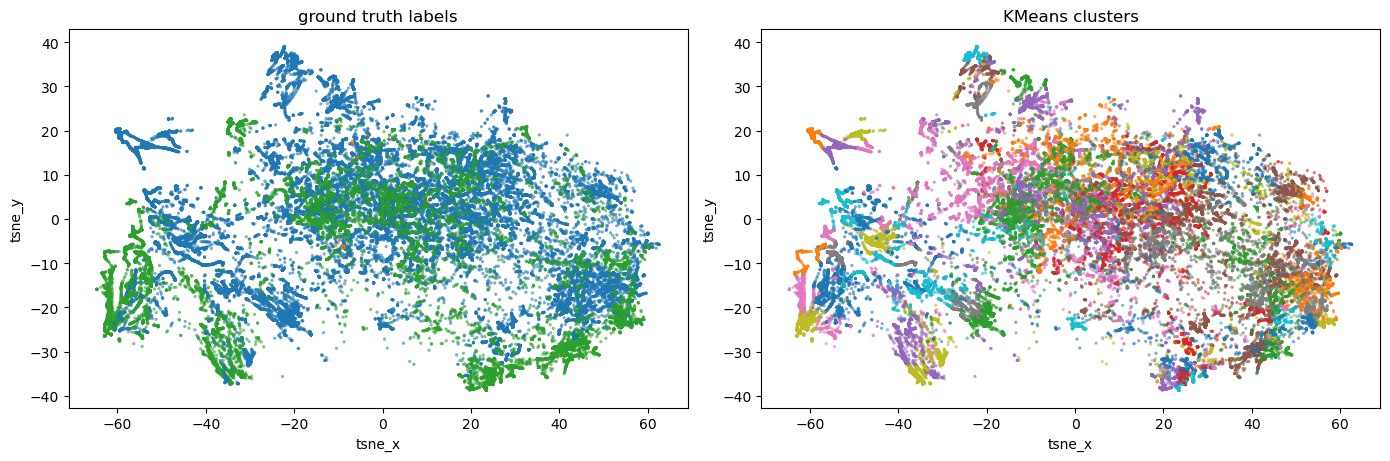

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(
    data=df, x="tsne_x", y="tsne_y", hue="labels-behavior",
    palette=sns.color_palette(n_colors=df["labels-behavior"].nunique()),
    lw=0, s=5, alpha=0.2, legend=None, ax=axes[0],
)
axes[0].set_aspect("equal")
axes[0].set_title("ground truth labels")

sns.scatterplot(
    data=df, x="tsne_x", y="tsne_y", hue="cluster",
    palette=sns.color_palette(n_colors=df["cluster"].nunique()),
    lw=0, s=5, alpha=0.2, legend=None, ax=axes[1],
)
axes[1].set_aspect("equal")
axes[1].set_title("KMeans clusters")

plt.tight_layout()
plt.show()


## Supervised classification (XGBoost)

Temporal-stacked scaled features → train/test split by sequence → per-class template subsampling → XGBoost multiclass + per-sequence inference. Writes `reports.json` and `summary.csv` next to the run.

NOTE:  This is fitting on a small subset of the whole data to demonstrate the workflow, so the fit quality will be lower than on the full dataset

In [33]:
ts_stack = TemporalStackingFeature(
    Inputs((scaler_result,)),
    params={
        "half": 2,
        "skip": 1,
        "use_temporal_stack": True,
        "sigma_stack": 2,
        "add_pool": False,
        "pool_stats": ("mean",),
        "fps": 30.0,
    },
)
ts_stack_result = dataset.run_feature(
    ts_stack, parallel_workers=4, parallel_mode="thread"
)


[feature:temporal-stack__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks] completed run_id=0.3-76a586f102 -> /home/jdavidson/ecodylic_local_sync/mosaic/example_datasets/mabe22-mouse-triplets/features/temporal-stack__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks/0.3-76a586f102


[temporal-stack__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks] Processed 10/10 sequences


In [34]:
labeled_templates = ExtractLabeledTemplates(
    Inputs((ts_stack_result,)),
    params={
        "labels": GroundTruthLabelsSource(),
        "n_per_class": 500,
        "test_fraction": 0.2,
    },
)
labeled_templates_result = dataset.run_feature(labeled_templates)

xgb = XgboostFeature(
    Inputs((ts_stack_result,)),
    params={
        "templates": ExtractLabeledTemplates.LabeledTemplatesArtifact().from_result(labeled_templates_result),
        "strategy": "multiclass",
        "default_class": 0,  # 0 = background
        "n_estimators": 10,
        "max_depth": 3,
    },
)
xgb_result = dataset.run_feature(xgb)


[extract-labeled-templates__from__temporal-stack__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks] Processed 10/10 sequences


[feature:extract-labeled-templates__from__temporal-stack__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks] completed run_id=0.1-310e5f7dfd -> /home/jdavidson/ecodylic_local_sync/mosaic/example_datasets/mabe22-mouse-triplets/features/extract-labeled-templates__from__temporal-stack__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks/0.1-310e5f7dfd
[feature:xgboost__from__temporal-stack__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks] completed run_id=0.1-3e6515c147 -> /home/jdavidson/ecodylic_local_sync/mosaic/example_datasets/mabe22-mouse-triplets/features/xgboost__from__temporal-stack__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks/0.1-3e6515c147


[xgboost__from__temporal-stack__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks] Processed 10/10 sequences


In [35]:
from mosaic.core.pipeline.run import feature_run_root

xgb_run_root = feature_run_root(dataset, xgb_result.feature, xgb_result.run_id)
summary_path = xgb_run_root / "summary.csv"
reports_path = xgb_run_root / "reports.json"

if summary_path.exists():
    summary_df = pd.read_csv(summary_path)
    display(summary_df)

if reports_path.exists():
    with open(reports_path) as f:
        reports = json.load(f)
    print(json.dumps(reports, indent=2))


,Unnamed: 0,precision,recall,f1-score,support
0,0,0.561056,0.680,0.614828,500.000
1,2,0.593909,0.468,0.523490,500.000
2,accuracy,0.574000,0.574,0.574000,0.574
3,macro avg,0.577482,0.574,0.569159,1000.000
4,weighted avg,0.577482,0.574,0.569159,1000.000


{
  "0": {
    "precision": 0.5610561056105611,
    "recall": 0.68,
    "f1-score": 0.6148282097649186,
    "support": 500.0
  },
  "2": {
    "precision": 0.5939086294416244,
    "recall": 0.468,
    "f1-score": 0.5234899328859061,
    "support": 500.0
  },
  "accuracy": 0.574,
  "macro avg": {
    "precision": 0.5774823675260927,
    "recall": 0.5740000000000001,
    "f1-score": 0.5691590713254123,
    "support": 1000.0
  },
  "weighted avg": {
    "precision": 0.5774823675260927,
    "recall": 0.574,
    "f1-score": 0.5691590713254123,
    "support": 1000.0
  }
}


### Visualize predictions on t-SNE

In [36]:
df_pred = load_values(
    dataset,
    [
        ResultColumn(column="predicted_label").from_result(xgb_result),
        ResultColumn(column="split").from_result(labeled_templates_result),
        ResultColumn(column="tsne_x").from_result(tsne_result),
        ResultColumn(column="tsne_y").from_result(tsne_result),
        GroundTruthLabelsSource(),
    ],
)
df_test = df_pred[df_pred["split"] == "test"]
print(f"{len(df_pred)} total, "
      f"{(df_pred['split']=='train').sum()} train, "
      f"{len(df_test)} test")


1296000 total, 1036800 train, 259200 test


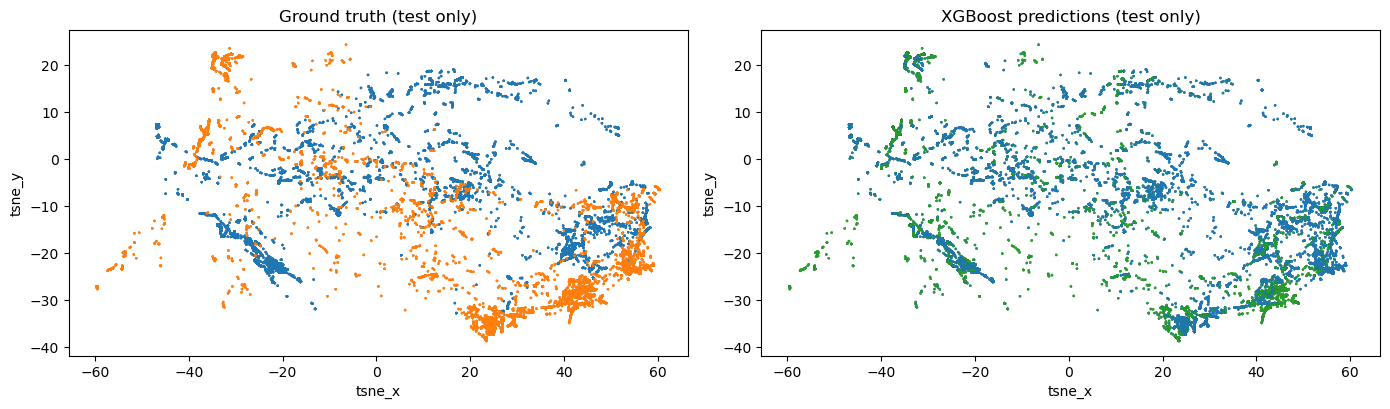

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, col, title in [
    (axes[0], "labels-behavior", "Ground truth (test only)"),
    (axes[1], "predicted_label", "XGBoost predictions (test only)"),
]:
    sns.scatterplot(
        data=df_test, x="tsne_x", y="tsne_y", hue=col,
        palette=sns.color_palette(n_colors=int(df_test[col].nunique())),
        lw=0, s=3, alpha=0.15, legend=None, ax=ax,
    )
    ax.set_aspect("equal")
    ax.set_title(title)
plt.tight_layout()
plt.show()


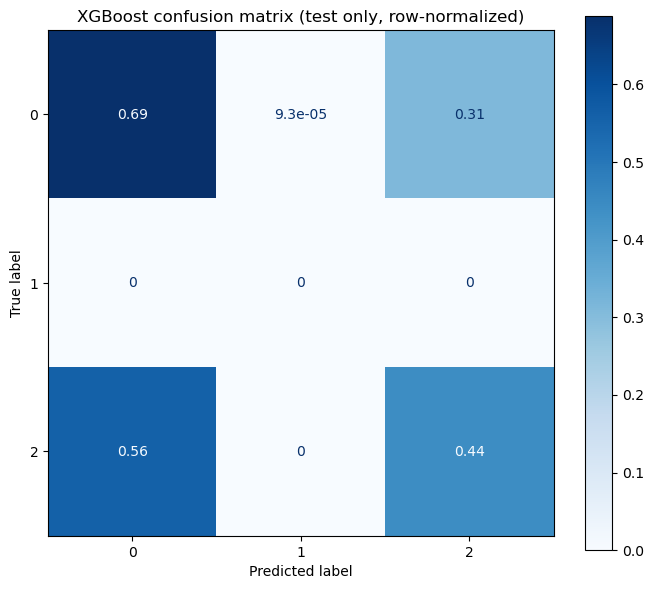

In [38]:
from sklearn.metrics import ConfusionMatrixDisplay

y_true = df_test["labels-behavior"].values
y_pred = df_test["predicted_label"].values

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred, normalize="true", cmap="Blues", ax=ax
)
ax.set_title("XGBoost confusion matrix (test only, row-normalized)")
plt.tight_layout()
plt.show()
